## Microgrid optimization with an algebraic approach using JuMP with H2 approach 

**H2 optimization** is a notebook that takes an existing model with H2 tank but try to simplify it replacing the sizing storage of H2 tanks in the model by a cost reducing the dimension of the problem. 

To do so, we will compare this infinite model with the finite model using the **sizing** of our components as **metrics**.

See image below to understand the difference :

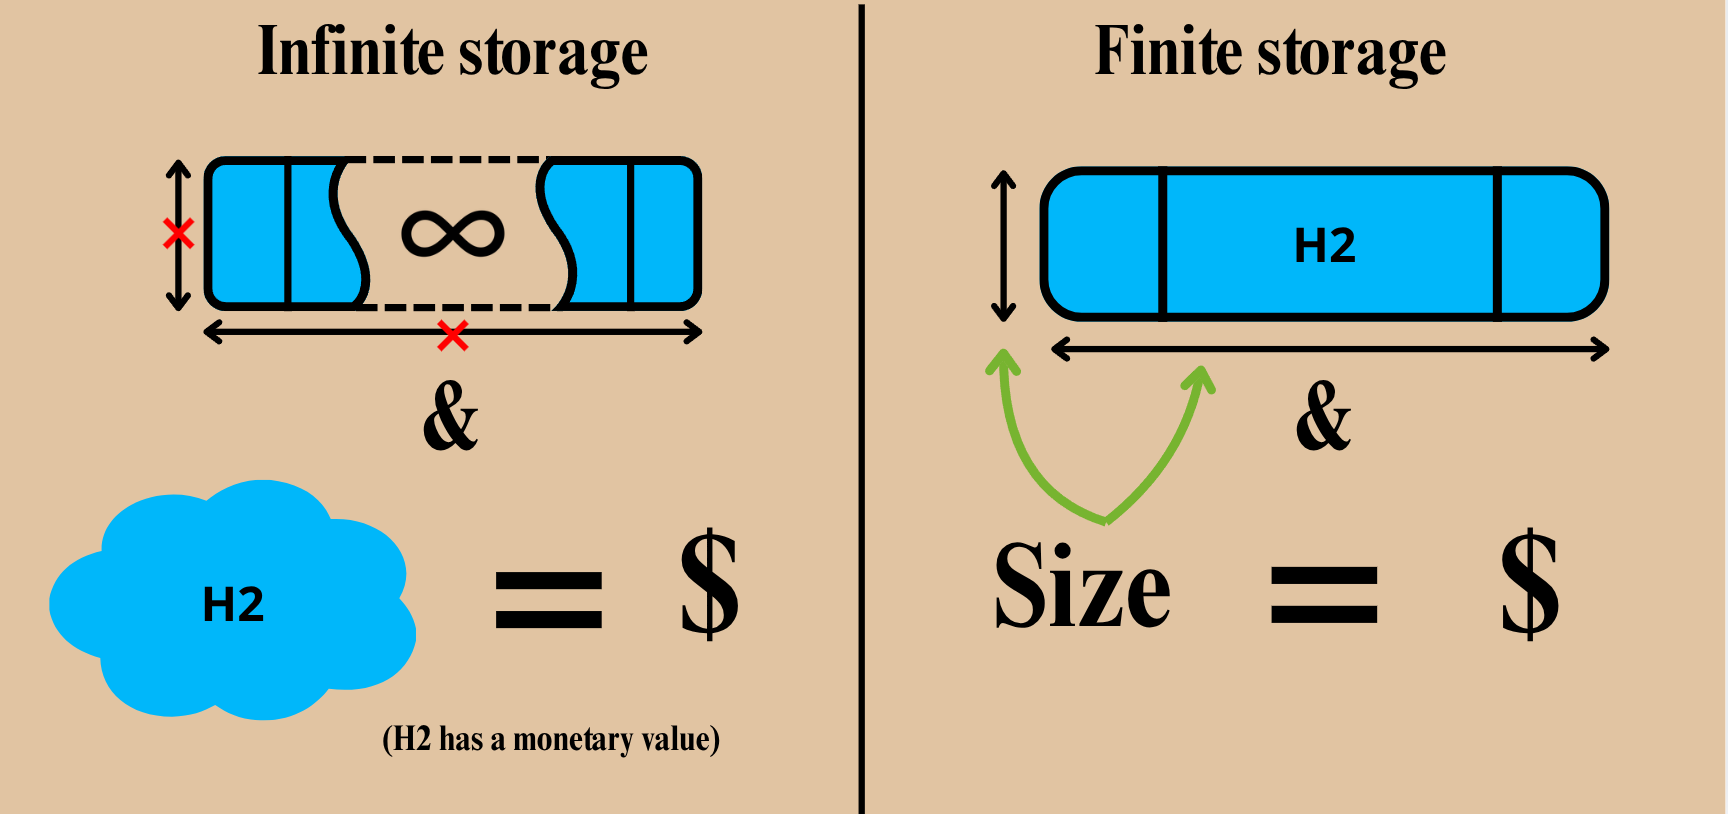

Initialization of the program

In [1]:
using Microgrids
using JuMP
using HiGHS
using DataFrames
using CSV

path = "../src"
cd(path)

include("../data/Microgrid_model_data.jl")
include("economics.jl")
include("simulate.jl")
include("create_microgrid.jl")
include("study.jl")
include("mg_jump.jl")

using Printf
using Plots
gr()

Threads.nthreads()

loading times series from Ouessant_data_2016.csv...


12

In [2]:
import Pkg
Pkg.status("Microgrids")

Status `~/.julia/environments/v1.12/Project.toml`
  [bd581358] Microgrids v0.10.5 `~/Documents/Centrale_Supelec/Projet_recherche/Microgrids.jl`


## Load Microgrid project data

In [3]:
const tseries = load_microgrid_tseries();

Pload_max = maximum(tseries.Pload) # kW

loading times series from Ouessant_data_2016.csv...


1707.0

In [4]:
ndays = 365 # 1 to 365
K = ndays*24 # h

ts_reduction_ndays(x) = ts_reduction(x, ndays)

println("working with $ndays days, that is $K timesteps")

td = collect((0:K-1)/24); # time in days

working with 365 days, that is 8760 timesteps


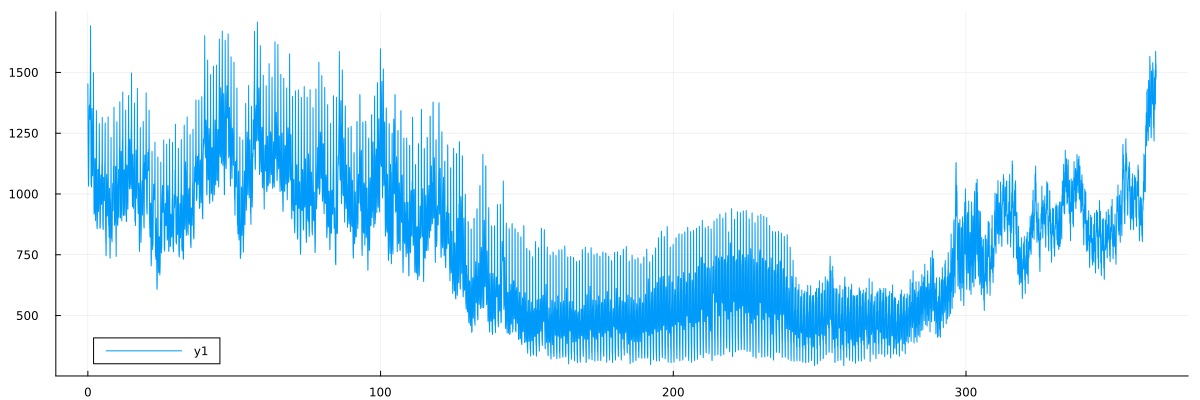

In [ ]:
fig = plot(td, tseries.Pload, size = (1200, 400), label = "load")
display(fig)

We **iterate** the optimization over a range of H2 price values to :

- Find out if we have an LCOE close the finite model
- Analyze the results of our optimizations

In [6]:
H2_price_range = range(0,7.5,20)

0.0:0.39473684210526316:7.5

In [7]:
results = Study(H2_price_range, true)
df_H2, df_Q = dataframe_result(results, H2_price_range, true)
show(df_H2, allcols=true, truncate=20)
show(df_Q, allcols=true, truncate=20)

 37.538806 seconds (34.55 M allocations: 1.957 GiB, 1.69% gc time, 8.97% compilation time: 13% of which was recompilation)
133.294869 seconds (45.85 M allocations: 2.512 GiB, 0.82% gc time, 8.88% compilation time: 4% of which was recompilation)
172.512382 seconds (54.72 M allocations: 2.944 GiB, 1.21% gc time, 6.86% compilation time: 4% of which was recompilation)
182.780865 seconds (63.58 M allocations: 3.367 GiB, 1.35% gc time, 6.48% compilation time: 4% of which was recompilation)
188.789830 seconds (66.62 M allocations: 3.459 GiB, 1.35% gc time, 6.27% compilation time: 4% of which was recompilation)
193.558577 seconds (75.49 M allocations: 3.904 GiB, 1.45% gc time, 6.12% compilation time: 4% of which was recompilation)
199.566049 seconds (84.35 M allocations: 4.331 GiB, 1.83% gc time, 5.93% compilation time: 4% of which was recompilation)
202.465492 seconds (87.38 M allocations: 4.408 GiB, 1.80% gc time, 5.85% compilation time: 4% of which was recompilation)
205.350750 seconds (96.

We export to CSV the dataframe for analysis

In [ ]:
export_to_csv(df_H2)

"../plots/CSV_results/result_for_H2_price_0.0_to_7.5.csv"

We find the minimum of this dataframe (this result is of limited interest, but it can be used as a start)

In [ ]:
id = argmin(df_H2.real_LCOE)
best_H2_price = df_H2.H2_price[id]

1.1842105263157894

Now that we have it we display the power rated corresponding

In [ ]:
best_row = df_H2[id, :]
show(best_row, allcols=true, truncate=20)

DataFrameRow
 Row │ H2_price  LCOE     real_LCOE  power_rated_fc  power_rated_ele  energy_rated_sto  power_rated_pv  power_rated_wind  status   cost_Q   range_Q  md                     mg                    
     │ Float64   Float64  Float64    Float64         Float64          Float64           Float64         Float64           String   Float64  Float64  Any                    Any                   
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   4 │  1.18421    116.8    123.806         1480.97              0.0           153.136         614.786           574.132  OPTIMAL   51.862  10689.0  Dict{String, Any}("w…  Microgrid{Float64}(P…

Considering this results we proceed to evaluate with the original H2 model

In [ ]:
results = Study(H2_price_range, false)
df = dataframe_result(results, H2_price_range, false)
show(df, allcols=true, truncate=20)

118.670316 seconds (3.43 M allocations: 206.833 MiB)
1×10 DataFrame
 Row │ LCOE     power_rated_fc  power_rated_ele  energy_rated_sto  LoH_rated  power_rated_pv  power_rated_wind  status   md                     mg                    
     │ Float64  Float64         Float64          Float64           Float64    Float64         Float64           String   Any                    Any                   
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ 268.347          1313.8          1615.09           1044.26    10759.0         1347.93           2697.83  OPTIMAL  Dict{String, Any}("w…  Microgrid{Float64}(P…

We extract the line with the closest LCOE to the finite storage one

In [ ]:
delta_LCOE = df_H2.real_LCOE .- df.LCOE[1]
id_closest = argmin(abs.(delta_LCOE))
show(df_H2[id_closest, :], allcols=true, truncate=20)

DataFrameRow
 Row │ H2_price  LCOE     real_LCOE  power_rated_fc  power_rated_ele  energy_rated_sto  power_rated_pv  power_rated_wind  status   cost_Q   range_Q  md                     mg                    
     │ Float64   Float64  Float64    Float64         Float64          Float64           Float64         Float64           String   Float64  Float64  Any                    Any                   
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  18 │  6.71053  196.889    257.851         1133.76          1647.28           4240.01         3059.63           2224.72  OPTIMAL  16.6916  2293.27  Dict{String, Any}("w…  Microgrid{Float64}(P…

## Analysis from the results

- The infinite storage version found solutions with very close cost compared to the finite model, but we still need to see if this solutions are realistic.

- The time to resolve the model is around a third compared to the finite_storage version which is interesting but we have to be careful as it is not a reliable measurement

- In this part we try to verify if :

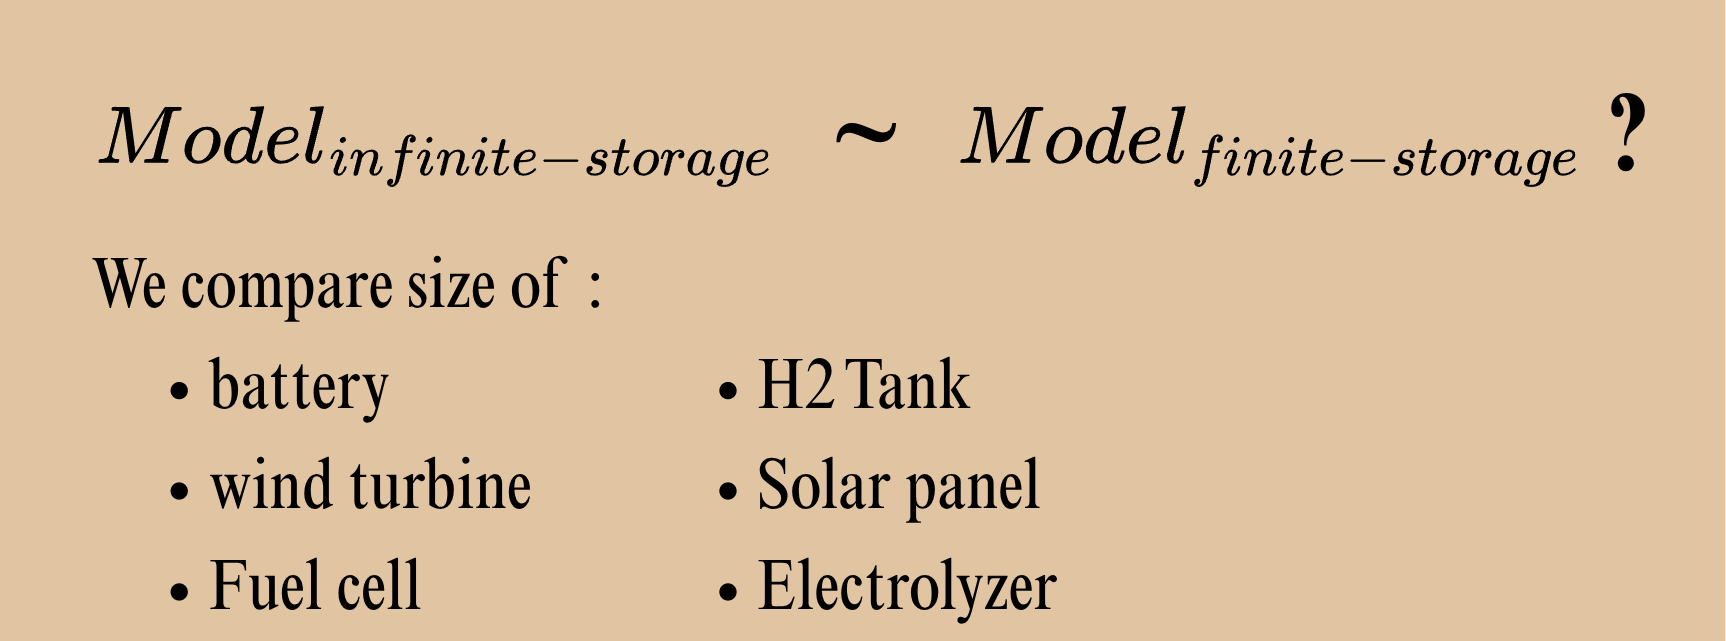

First we plot the trajectory of Q for the **infinite storage model** with the closest LCOE

In [ ]:
H2_price_closest = df_H2.H2_price[id_closest]
df_Q_closest = df_Q[df_Q.H2_price .== H2_price_closest, :]
df_Q_wide = unstack(df_Q, :time, :H2_price, :Q);

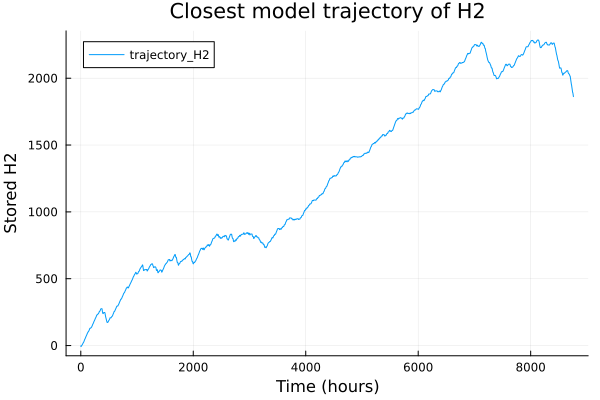

In [ ]:
plot(df_Q_closest.time,
     df_Q_closest.Q,
     xlabel = "Time (hours)",
     ylabel = "Stored H2",
     label = "trajectory_H2",
     title = "Closest model trajectory of H2",)

We can see that with our relaxed model, we have a **difference** compared to the finite storage model : the amount of H2 is **not cycled** throughout the year.

Now we plot the LCOE as a function of H2_price

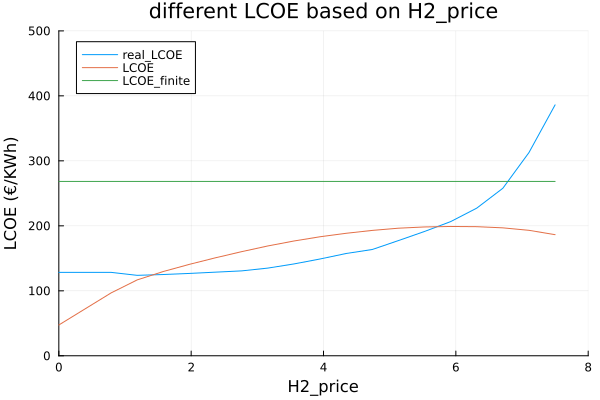

In [ ]:
LCOE_finite = df.LCOE .* ones(length(H2_price_range))
plot(H2_price_range,
     [df_H2.real_LCOE,df_H2.LCOE, LCOE_finite],
     xlabel = "H2_price",
     ylabel = "LCOE (€/KWh)",
     label = ["real_LCOE" "LCOE" "LCOE_finite"],
     title = "different LCOE based on H2_price",
)
xlims!(0, 8)
ylims!(0,500)

Sizing of fuel cells as a function of H2_price

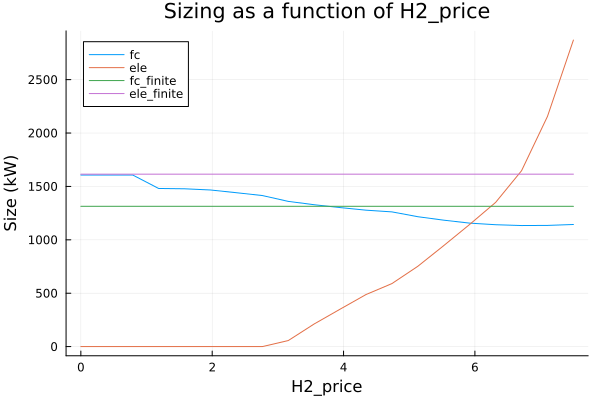

In [ ]:
fc_finite = df.power_rated_fc .* ones(length(H2_price_range))
plot(H2_price_range,
     [df_H2.power_rated_fc, fc_finite],
     xlabel = "H2_price",
     ylabel = "Size (kW)",
     label = ["fc" "fc_finite"],
     title = "Sizing as a function of H2_price",)

Sizing of electrolyzer as a function of H2_price

In [ ]:
ele_finite = df.power_rated_ele .* ones(length(H2_price_range))
plot(H2_price_range,
     [df_H2.power_rated_ele, ele_finite],
     xlabel = "H2_price",
     ylabel = "Size (kW)",
     label = [ "ele" "ele_finite"],
     title = "Sizing as a function of H2_price",)

Sizing of the renewable energies as function of H2_price

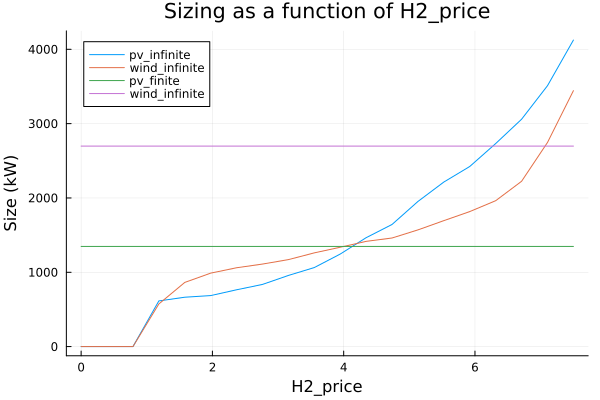

In [ ]:
pv_finite = df.power_rated_pv .* ones(length(H2_price_range))
plot(H2_price_range,
     [df_H2.power_rated_pv,df_H2.power_rated_wind, pv_finite, wind_finite],
     xlabel = "H2_price",
     ylabel = "Size (kW)",
     label = ["pv_infinite" "pv_finite"],
     title = "Sizing as a function of H2_price",)

Sizing of wind turbines

In [ ]:
wind_finite = df.power_rated_wind .* ones(length(H2_price_range))
plot(H2_price_range,
     [df_H2.power_rated_wind, wind_finite],
     xlabel = "H2_price",
     ylabel = "Size (kW)",
     label = [ "wind_infinite" "wind_infinite"],
     title = "Sizing as a function of H2_price",)

Sizing of storage as function of H2_price

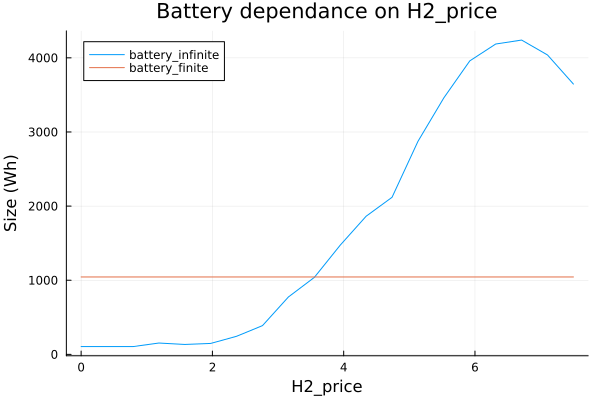

In [ ]:
sto_finite = df.energy_rated_sto .* ones(length(H2_price_range))
plot(H2_price_range,
     [df_H2.energy_rated_sto, sto_finite],
     xlabel = "H2_price",
     ylabel = "Size (Wh)",
     label = ["battery_infinite" "battery_finite"],
     title = "Battery dependance on H2_price",)

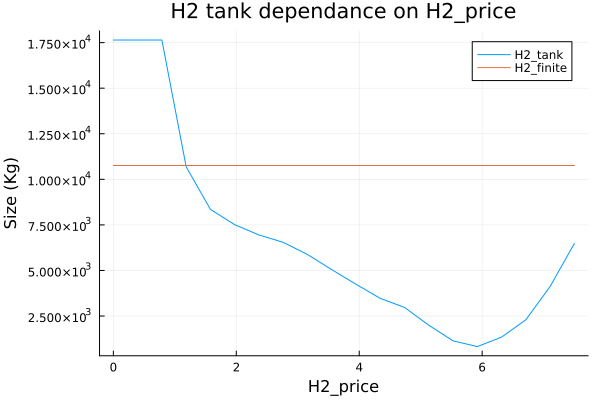

In [ ]:
Q_finite = df.LoH_rated .* ones(length(H2_price_range))
plot(H2_price_range,
     [df_H2.range_Q, Q_finite],
     xlabel = "H2_price",
     ylabel = "Size (Kg)",
     label = ["H2_tank" "H2_finite"],
     title = "H2 tank dependance on H2_price",)

Considering this results, we need to verify if the sizing of the solutions is indeed correct

In [ ]:
mg_closest = df_H2.mg[id_closest];
md_closest = df_H2.md[id_closest];

traj_opt, stats_opt, costs_opt = simulate_alg(mg_closest, md_closest);

Pload = traj_opt.power_net_load;
Pele  = traj_opt.Pelyz;
Pfc   = traj_opt.Pfc;
Pren  = traj_opt.Prenew_pot;
Ebatt = traj_opt.Ebatt;

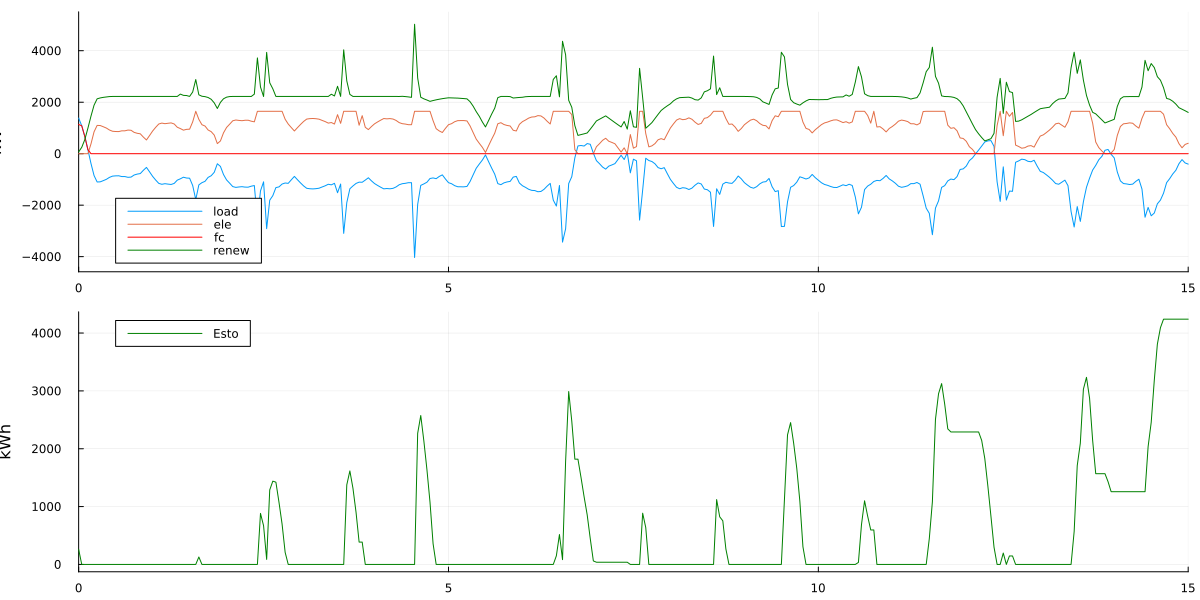

In [ ]:
fig = plot_oper_traj(td, Pload, Pele, Pfc, Pren, Ebatt, xlim = (0, 15))
display(fig)

## TO DO

- Compare the results using another pivot point than the LCOE (wind size, pv size, ...)

- Implement multithreading

- Verify and iterate the code to try and find if inaccuracies led to false results